# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import Huber
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from datetime import datetime

# Data Understanding

In [2]:
df = pd.read_csv('/content/DataProduksi.csv')
df

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,Jan-09,1427.10,50.00,8.80
1,Feb-09,1188.00,45.50,7.90
2,Mar-09,1346.70,40.10,8.50
3,Apr-09,1193.50,38.80,9.30
4,May-09,1239.50,47.20,10.30
...,...,...,...,...
115,Aug-18,2075.95,35.32,5.99
116,Sep-18,2093.69,49.37,6.78
117,Oct-18,2075.70,51.21,8.12
118,Nov-18,1931.94,48.77,8.48


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tanggal       120 non-null    object 
 1   Minyak Sawit  120 non-null    float64
 2   Karet Kering  120 non-null    float64
 3   Teh           120 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.9+ KB


# Preprocessing

## Change date format

In [4]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%b-%y').dt.strftime('%Y-%m')
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,1427.1,50.0,8.8
1,2009-02,1188.0,45.5,7.9
2,2009-03,1346.7,40.1,8.5
3,2009-04,1193.5,38.8,9.3
4,2009-05,1239.5,47.2,10.3


## Normalization

In [5]:
scaler = MinMaxScaler()
columns = ['Minyak Sawit', 'Karet Kering', 'Teh']
df[columns] = scaler.fit_transform(df[columns])
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,0.434536,0.351266,0.655963
1,2009-02,0.248938,0.268072,0.449541
2,2009-03,0.372127,0.168238,0.587156
3,2009-04,0.253208,0.144204,0.770642
4,2009-05,0.288915,0.299501,1.000000


## Separating DataFrame Columns into Separate Variables

In [6]:
dates = df['Tanggal'].values
minyak_sawit = df['Minyak Sawit'].values
karet_kering = df['Karet Kering'].values
teh = df['Teh'].values

## Windowed Dataset

In [7]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1:]))
    return ds.batch(batch_size).prefetch(1)

## Split Dataset

In [8]:
def split_data(data):
  # train_size = int(len(data) * 0.8)
  time = np.array(range(len(data)))
  series = np.array(data)
  # X_train = series[:train_size]
  # X_test = series[train_size:]
  # y_train = time[:train_size]
  # y_test = time[train_size:]

  X_train, X_test, y_train, y_test = train_test_split(series, time,test_size=0.2, shuffle=False)
  return X_train, X_test, y_train, y_test

# LSTM model

In [9]:
def model_lstm(data, attribute_name):
  X_train, X_test, y_train, y_test = split_data(data)
  model = Sequential([
    LSTM(60, return_sequences=True),
    LSTM(60),
    Dense(30, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="relu"),
    Dropout(0.2),
    Dense(1)])
  
  train_set = windowed_dataset(
      X_train, window_size=60,
      batch_size=100,
      shuffle_buffer=1000
  )

  valid_set = windowed_dataset(
      X_test, window_size=60,
      batch_size=100,
      shuffle_buffer=1000
  )
  
  optimizer = SGD(learning_rate=1.0000e-04, momentum=0.9)
  model.compile(loss=tf.keras.losses.Huber(),
                optimizer=optimizer,
                metrics=["mae"])

  history = model.fit(train_set, epochs=30,
                      validation_data=valid_set,
                      batch_size=128)
  
  y_pred = model.predict(X_test.reshape(-1,1))
  # mae = mean_absolute_error(y_test, y_pred)
  # r2 = r2_score(y_test, y_pred)
  # print('R2 Score:', r2)
  # print('MAE:', mae)

  plt.figure(figsize=(20, 5))
  plt.plot(y_test, label='Actual')
  plt.plot(y_pred, label='Predicted')
  plt.legend()
  plt.title(f'Data {attribute_name}')
  plt.xlabel('Bulan')
  plt.ylabel('Produksi')
  plt.xticks(rotation=45)
  plt.show()

  # plt.plot(history.history['loss'], label='Loss')
  # plt.plot(history.history['mae'], label='MAE')
  # plt.title(f'LSTM {attribute_name}')
  # plt.ylabel('Epoch')
  # plt.legend()
  # plt.show()

# SVR Model

In [10]:
def model_svr(data, attribute_name):
  X_train, X_test, y_train, y_test = split_data(data)
  svr = SVR()
  svr.fit(X_train.reshape(-1,1), y_train)
  y_pred = svr.predict(X_test.reshape(-1,1))

  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print('R2 Score:', r2)
  print('MAE:', mae)
  plt.figure(figsize=(20, 5))
  plt.plot(dates[len(X_train):], y_test, label='Data Test')
  plt.plot(dates[len(X_train):], y_pred, label='Prediksi')
  plt.legend()
  plt.title(f'Data {attribute_name}')
  plt.xlabel('Bulan')
  plt.ylabel('Produksi')
  plt.xticks(rotation=50)
  plt.show()

# LSTM Evaluation

## Minyak Sawit

Epoch 1/30
1/1 [==============================] - 13s 13s/step - loss: 0.1886 - mae: 0.6026
Epoch 2/30
1/1 [==============================] - 0s 330ms/step - loss: 0.1853 - mae: 0.5971
Epoch 3/30
1/1 [==============================] - 0s 209ms/step - loss: 0.1810 - mae: 0.5897
Epoch 4/30
1/1 [==============================] - 0s 223ms/step - loss: 0.1861 - mae: 0.5984
Epoch 5/30
1/1 [==============================] - 0s 209ms/step - loss: 0.1882 - mae: 0.6022
Epoch 6/30
1/1 [==============================] - 0s 195ms/step - loss: 0.1880 - mae: 0.6020
Epoch 7/30
1/1 [==============================] - 0s 207ms/step - loss: 0.1870 - mae: 0.6003
Epoch 8/30
1/1 [==============================] - 0s 202ms/step - loss: 0.1875 - mae: 0.6000
Epoch 9/30
1/1 [==============================] - 0s 190ms/step - loss: 0.1851 - mae: 0.5971
Epoch 10/30
1/1 [==============================] - 0s 271ms/step - loss: 0.1846 - mae: 0.5956
Epoch 11/30
1/1 [==============================] - 0s 283ms/step - los

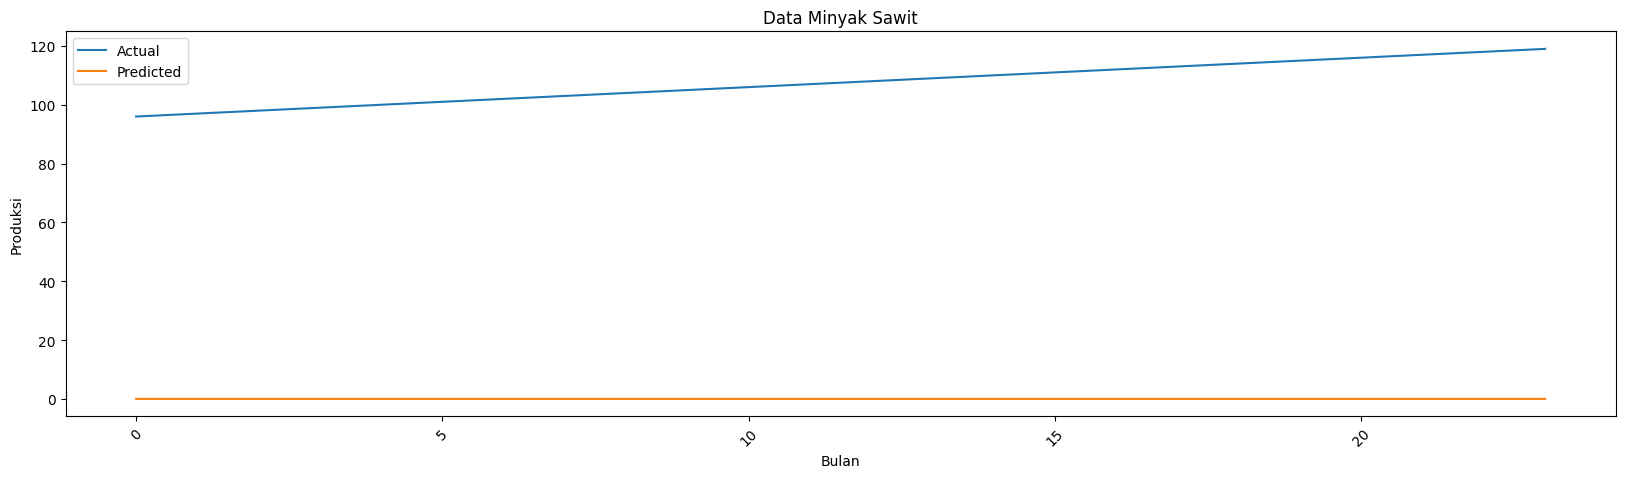

In [11]:
model_lstm(minyak_sawit, 'Minyak Sawit')

## Karet Kering

Epoch 1/30
1/1 [==============================] - 6s 6s/step - loss: 0.0829 - mae: 0.3019
Epoch 2/30
1/1 [==============================] - 0s 119ms/step - loss: 0.0850 - mae: 0.3051
Epoch 3/30
1/1 [==============================] - 0s 104ms/step - loss: 0.0859 - mae: 0.3097
Epoch 4/30
1/1 [==============================] - 0s 103ms/step - loss: 0.0836 - mae: 0.3054
Epoch 5/30
1/1 [==============================] - 0s 106ms/step - loss: 0.0851 - mae: 0.3046
Epoch 6/30
1/1 [==============================] - 0s 107ms/step - loss: 0.0829 - mae: 0.3052
Epoch 7/30
1/1 [==============================] - 0s 105ms/step - loss: 0.0835 - mae: 0.3043
Epoch 8/30
1/1 [==============================] - 0s 103ms/step - loss: 0.0832 - mae: 0.3040
Epoch 9/30
1/1 [==============================] - 0s 101ms/step - loss: 0.0830 - mae: 0.3059
Epoch 10/30
1/1 [==============================] - 0s 103ms/step - loss: 0.0813 - mae: 0.3023
Epoch 11/30
1/1 [==============================] - 0s 99ms/step - loss: 

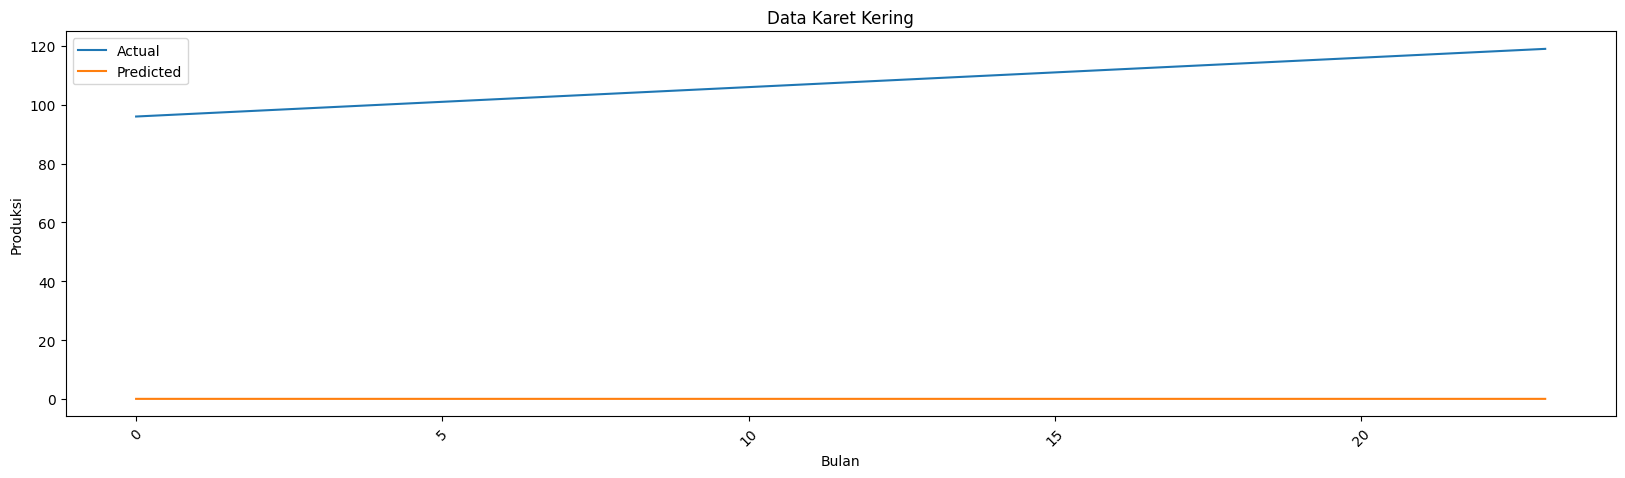

In [12]:
model_lstm(karet_kering, 'Karet Kering')

## Teh

Epoch 1/30
1/1 [==============================] - 6s 6s/step - loss: 0.0914 - mae: 0.3730
Epoch 2/30
1/1 [==============================] - 0s 117ms/step - loss: 0.0882 - mae: 0.3683
Epoch 3/30
1/1 [==============================] - 0s 109ms/step - loss: 0.0909 - mae: 0.3723
Epoch 4/30
1/1 [==============================] - 0s 99ms/step - loss: 0.0899 - mae: 0.3688
Epoch 5/30
1/1 [==============================] - 0s 107ms/step - loss: 0.0912 - mae: 0.3695
Epoch 6/30
1/1 [==============================] - 0s 109ms/step - loss: 0.0929 - mae: 0.3752
Epoch 7/30
1/1 [==============================] - 0s 104ms/step - loss: 0.0898 - mae: 0.3645
Epoch 8/30
1/1 [==============================] - 0s 109ms/step - loss: 0.0893 - mae: 0.3660
Epoch 9/30
1/1 [==============================] - 0s 112ms/step - loss: 0.0885 - mae: 0.3671
Epoch 10/30
1/1 [==============================] - 0s 105ms/step - loss: 0.0921 - mae: 0.3756
Epoch 11/30
1/1 [==============================] - 0s 102ms/step - loss: 

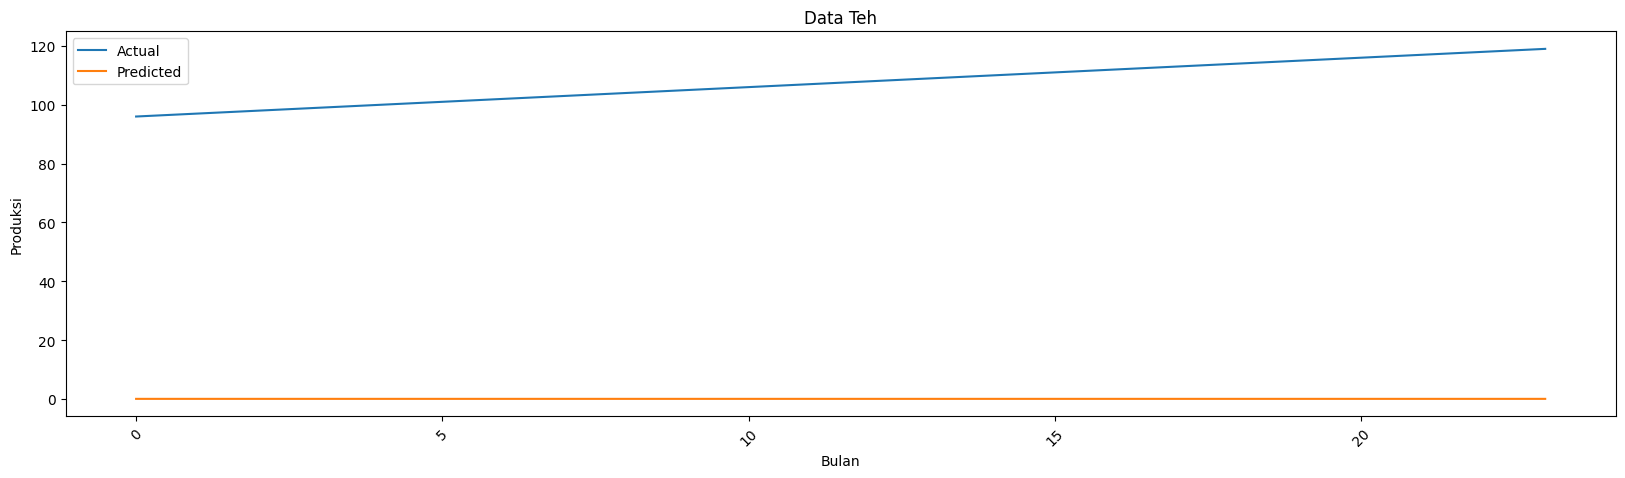

In [13]:
model_lstm(teh, 'Teh')

# SVR Evaluation

## Minyak Sawit

R2 Score: -43.412619284414234
MAE: 45.137193667434225


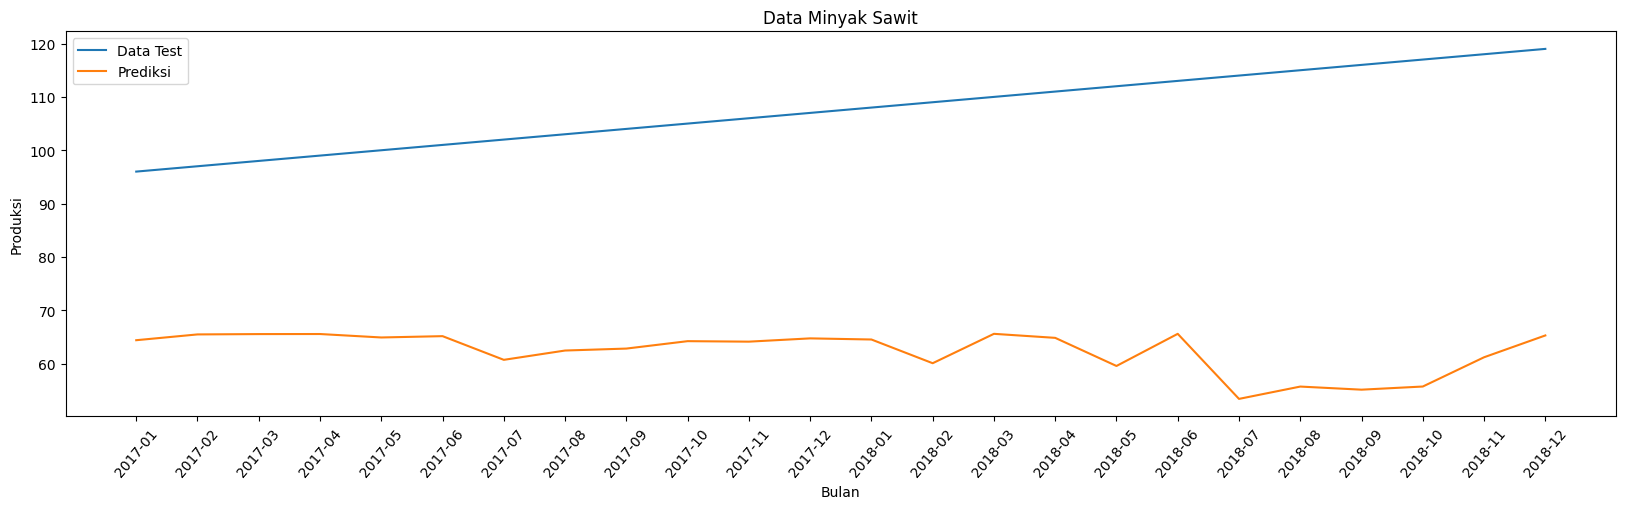

In [14]:
model_svr(minyak_sawit, 'Minyak Sawit')

## Karet Kering

R2 Score: -70.50069989347377
MAE: 57.723172253512814


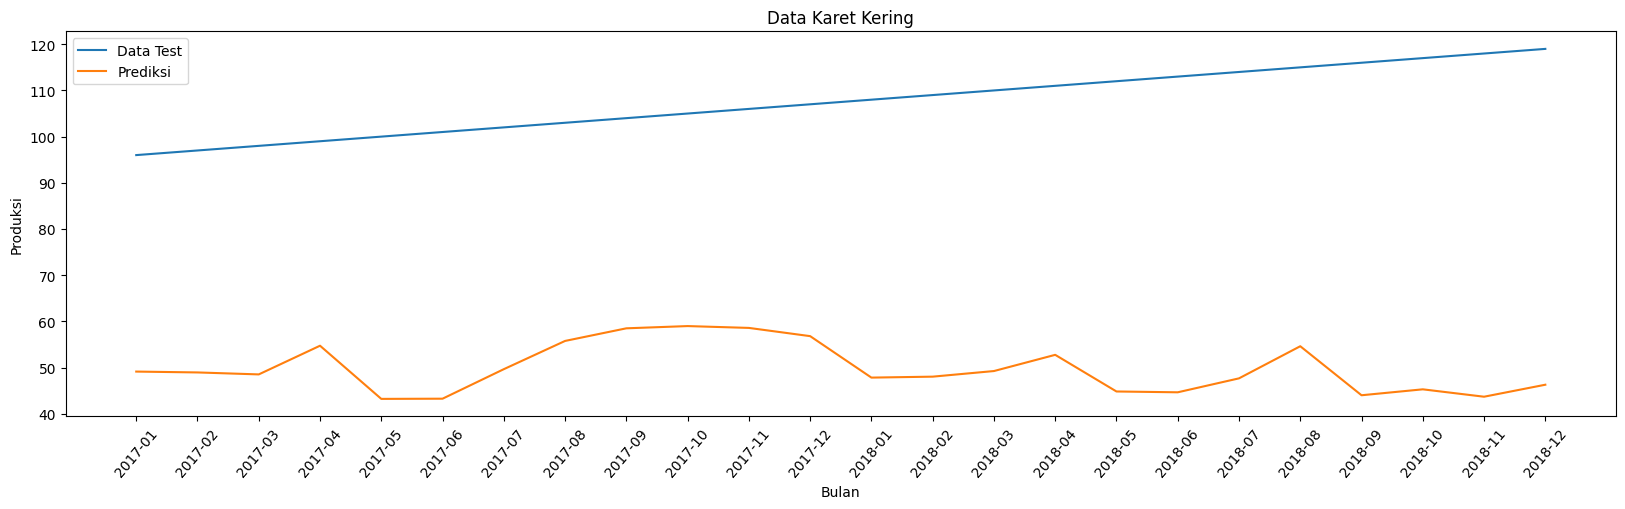

In [15]:
model_svr(karet_kering, 'Karet Kering')

## Teh

R2 Score: -76.6744991575816
MAE: 60.612724099021214


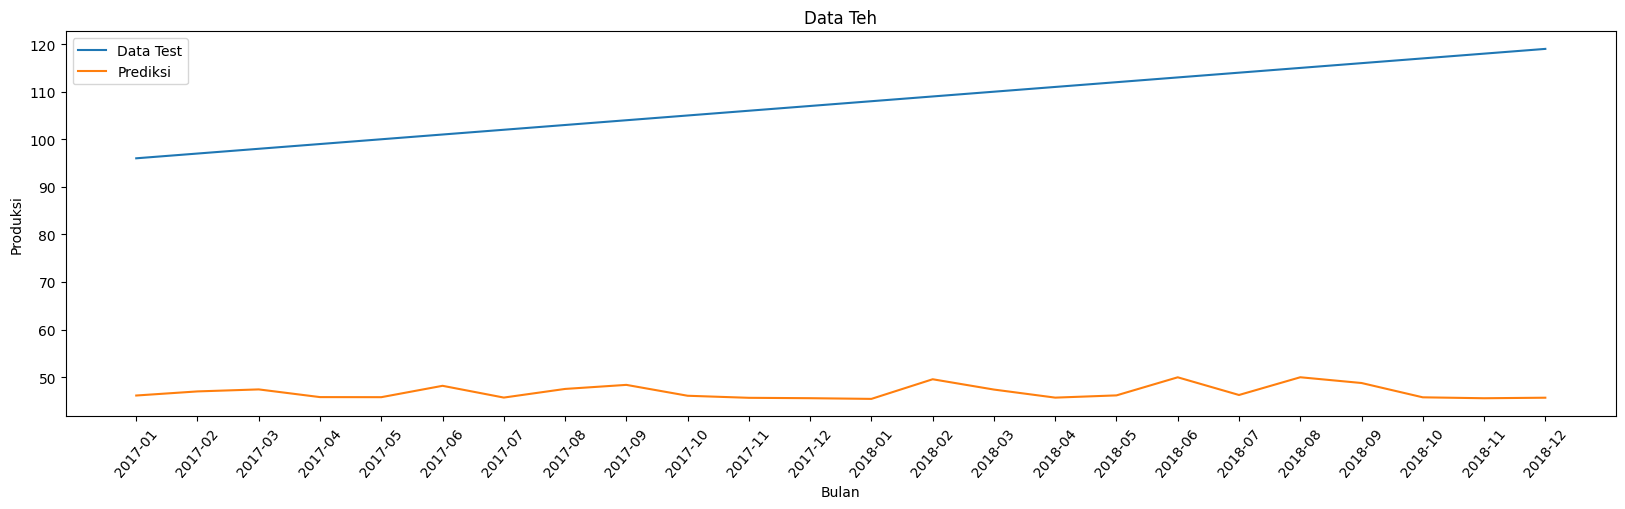

In [16]:
model_svr(teh, 'Teh')